In [1]:
import pandas as pd
import matplotlib.pyplot as plt

*used the data from **CRTS** of Mkn421  http://nesssi.cacr.caltech.edu/DataRelease/*

In [2]:
df = pd.read_csv("Mkn421.csv") 
print(df.head())

        MasterID    Mag  Magerr         RA       Dec          MJD  Blend
0  1138048033090  12.22    0.05  166.11401  38.20901  54095.39818      0
1  1138048033090  12.22    0.05  166.11404  38.20902  54095.42301      0
2  1138048033090  12.61    0.06  166.11394  38.20892  53902.22979      0
3  1138048033090  12.68    0.06  166.11401  38.20893  53902.23176      0
4  1138048033090  12.60    0.06  166.11423  38.20907  53902.23276      0


*plot the **Light Curve** V(magnitude) vs detection Date for* **Mkn421**

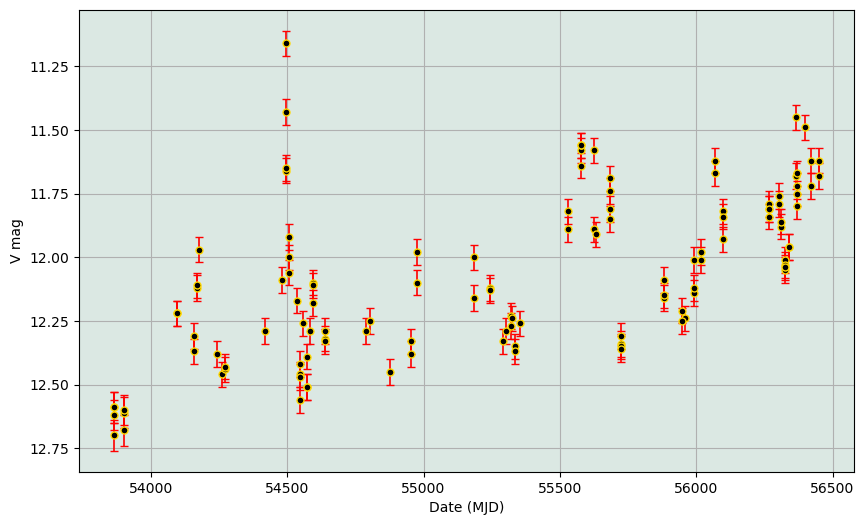

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("#dbe8e3") 
ax.grid(True)

ax.errorbar(
    df["MJD"],       # x-axis-time
    df["Mag"],       # y-axis-magnitude
    yerr=df["Magerr"],  # error bars
    fmt="o",  #plot circular points
    markersize=5, #data point size
    color="black",
    ecolor="red", #error bar color
    elinewidth=1.2, #error bar thickness
    capsize=3,
    markerfacecolor="black",
    markeredgecolor="gold",
    linestyle="none",
    label="Mkn421"
)  


ax.set_xlabel("Date (MJD)")
ax.set_ylabel("V mag")
ax.tick_params(axis="both")

ax.invert_yaxis()   #starts from higher to lower as we go up in the y-axis

plt.show()

**1. What are the dates that MJD corresponds to? What date is 54000 MJD?**


*Julian Day Number is an integer counter of the days beginning at noon 1 January 4713 B.C., which is Julian Day Number 0, https://core2.gsfc.nasa.gov/time/mjd2000.html, MJ day calculator https://core2.gsfc.nasa.gov/time/julian.html* 

*Julian day is a continuous count of days from the beginning of the Julian period and The MJD has a starting point of midnight on November 17, 1858, and is computed by MJD = JD − 2400000.5*



**2. Why do we have values of light curve within this range? Learn about CRTS**
*physical nature of the celestial object and the timeframe of the observation*


In [4]:
from astropy.time import Time

mjd = 54000
t = Time(mjd, format='mjd')

print(t.iso) 

2006-09-22 00:00:00.000


*Outliers were removed by excluding values lying more than three standard deviations above or below the mean.*
**No outliers were removed, all the data lies within three STD of the mean**

In [5]:
import numpy as np

df = pd.read_csv("Mkn421.csv")

mean = df["Mag"].mean()
std = df["Mag"].std()

lower_limit = mean - 3 * std
upper_limit = mean + 3 * std

clean_df = df[np.abs(df["Mag"] - mean) <= 3 * std]
outliers = df[np.abs(df["Mag"] - mean) > 3 * std]

print("Total rows:", len(df))
print("Rows after clipping:", len(clean_df))
print("Outliers removed:", len(outliers))
print("Mean:", mean)
print("Std:", std)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Total rows: 120
Rows after clipping: 120
Outliers removed: 0
Mean: 12.07075
Std: 0.3179137944038743
Lower limit: 11.117008616788377
Upper limit: 13.024491383211624


*plot the Lightcurve for* **Mkn501**

In [6]:
df1 = pd.read_csv("Mkn501.csv") 
print(df1.head())

        MasterID    Mag  Magerr         RA       Dec          MJD  Blend
0  1140070008841  12.42    0.05  253.46785  39.76028  53552.34825      0
1  1140070008841  12.44    0.05  253.46785  39.76029  53552.35698      0
2  1140070008841  12.41    0.05  253.46785  39.76032  53552.36573      0
3  1140070008841  12.42    0.05  253.46786  39.76034  53552.37444      0
4  1140070008841  12.44    0.05  253.46783  39.76026  53561.20974      0


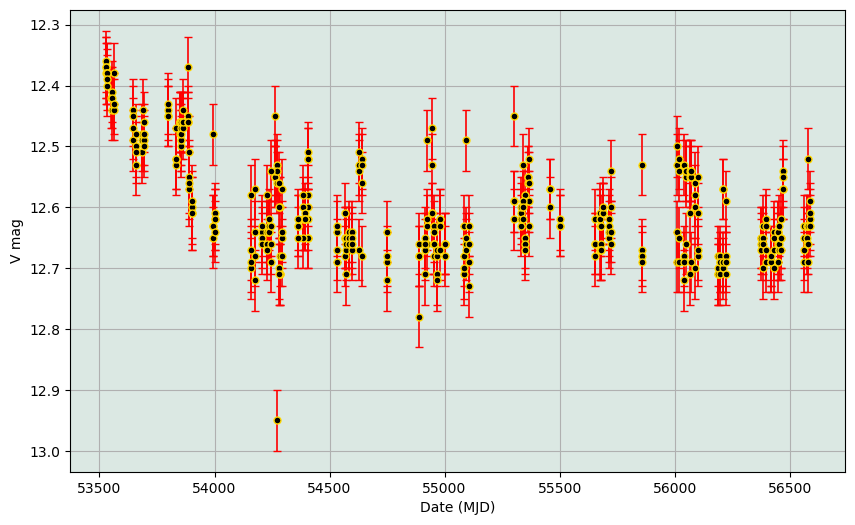

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("#dbe8e3") 
ax.grid(True)

ax.errorbar(
    df1["MJD"],       # x-axis-time
    df1["Mag"],       # y-axis-magnitude
    yerr=df1["Magerr"],  # error bars
    fmt="o",  #plot circular points
    markersize=5, #data point size
    color="black",
    ecolor="red", #error bar color
    elinewidth=1.2, #error bar thickness
    capsize=3,
    markerfacecolor="black",
    markeredgecolor="gold",
    linestyle="none",
    label="Mkn421"
)  


ax.set_xlabel("Date (MJD)")
ax.set_ylabel("V mag")
ax.tick_params(axis="both")

ax.invert_yaxis()   #starts from higher to lower as we go up in the y-axis

plt.show()

In [10]:
import numpy as np

df1 = pd.read_csv("Mkn501.csv")

mean = df1["Mag"].mean()
std = df1["Mag"].std()

lower_limit = mean - 3 * std
upper_limit = mean + 3 * std

clean_df1 = df1[np.abs(df1["Mag"] - mean) <= 3 * std]
outliers = df1[np.abs(df1["Mag"] - mean) > 3 * std]

print("Total rows:", len(df1))
print("Rows after clipping:", len(clean_df1))
print("Outliers removed:", len(outliers))
print("Mean:", mean)
print("Std:", std)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
clean_df1.to_csv("Mkn501_cleaned.csv", index=False)

Total rows: 373
Rows after clipping: 372
Outliers removed: 1
Mean: 12.602198391420911
Std: 0.08609505435564971
Lower limit: 12.343913228353962
Upper limit: 12.86048355448786


*Outliers were removed by excluding values lying more than three standard deviations above or below the mean.* **only one data point was removed**

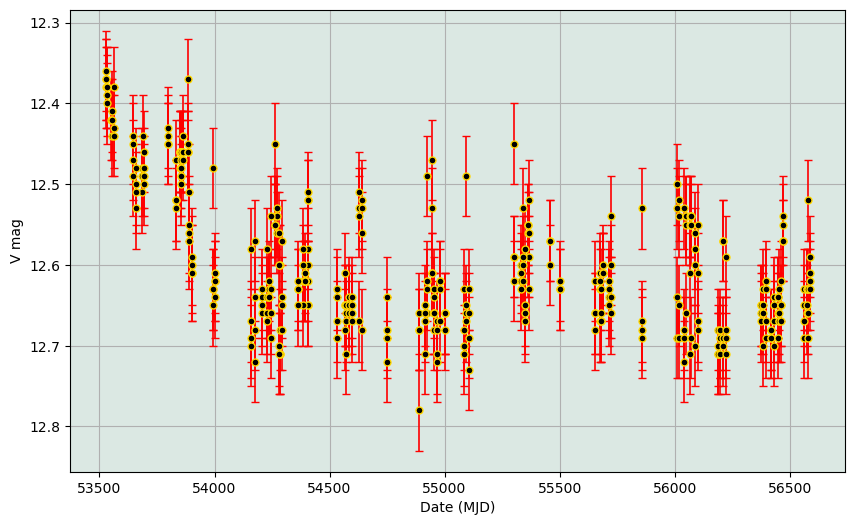

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("#dbe8e3") 
ax.grid(True)

ax.errorbar(
    clean_df1["MJD"],       # x-axis-time
    clean_df1["Mag"],       # y-axis-magnitude
    yerr=clean_df1["Magerr"],  # error bars
    fmt="o",  #plot circular points
    markersize=5, #data point size
    color="black",
    ecolor="red", #error bar color
    elinewidth=1.2, #error bar thickness
    capsize=3,
    markerfacecolor="black",
    markeredgecolor="gold",
    linestyle="none",
    label="Mkn421"
)  


ax.set_xlabel("Date (MJD)")
ax.set_ylabel("V mag")
ax.tick_params(axis="both")

ax.invert_yaxis()   #starts from higher to lower as we go up in the y-axis

plt.show()